# **HW13: Neural Networks**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

# **Neural Networks with Face Classification and Wine Embeddings**

This homework uses **new datasets** that are different from the in-class neural-network notebooks. We will still practice the same core lecture ideas, but in a different setting:

1. **Classify face images** using a feed-forward neural network on the `sklearn` Olivetti faces dataset
2. **Learn low-dimensional embeddings** of wine chemistry data using an autoencoder on the `sklearn` wine dataset

## **Key Neural Network Ideas**

Across both parts, we will work with the main concepts from the lecture:
- **Layers and activation functions** to model non-linear relationships
- **Forward propagation** to compute predictions or reconstructions
- **Loss functions** to measure model error
- **Backpropagation** to compute gradients
- **Optimizers** to update model weights
- **Embeddings / latent representations** to compress data into a lower-dimensional space

## **What makes this homework different from the IC notebooks?**

- Instead of **MNIST**, we will use the **Olivetti faces** dataset from `sklearn`
- Instead of training word embeddings on **20 Newsgroups**, we will learn **latent embeddings** for wines using an autoencoder

This keeps the homework aligned with the lecture while avoiding reuse of the same in-class assignments.

## **Import Libraries**

We start by loading the tools needed for both parts of the homework.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_olivetti_faces, load_wine
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# **Part 1: Face Classification with a Feed-Forward Neural Network**

We will use the `sklearn` **Olivetti faces** dataset. Each example is a 64x64 grayscale image of a face, flattened into 4,096 input features.

This task is still an image-classification problem, but it is a more difficult one than digit recognition because:
- there are **40 classes** instead of 10
- there are only **10 images per person**
- the model must distinguish subtle facial differences rather than broad digit shapes

## **Load the Olivetti Faces Dataset**

The Olivetti faces dataset contains 400 grayscale face images: 10 images each for 40 different people.

In [3]:
faces = fetch_olivetti_faces(download_if_missing=True)
X = faces.data.astype(np.float32)
y = faces.target.astype(np.int64)
images = faces.images

print(f"Feature matrix shape: {X.shape}")
print(f"Image tensor shape: {images.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Images per class: {np.bincount(y)[:5]} ...")
print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\cruzj\scikit_learn_data
Feature matrix shape: (400, 4096)
Image tensor shape: (400, 64, 64)
Number of classes: 40
Images per class: [10 10 10 10 10] ...
Pixel range: [0.000, 1.000]


## **Inspect a Few Examples**

Before training, let's visualize several sample faces from the dataset.

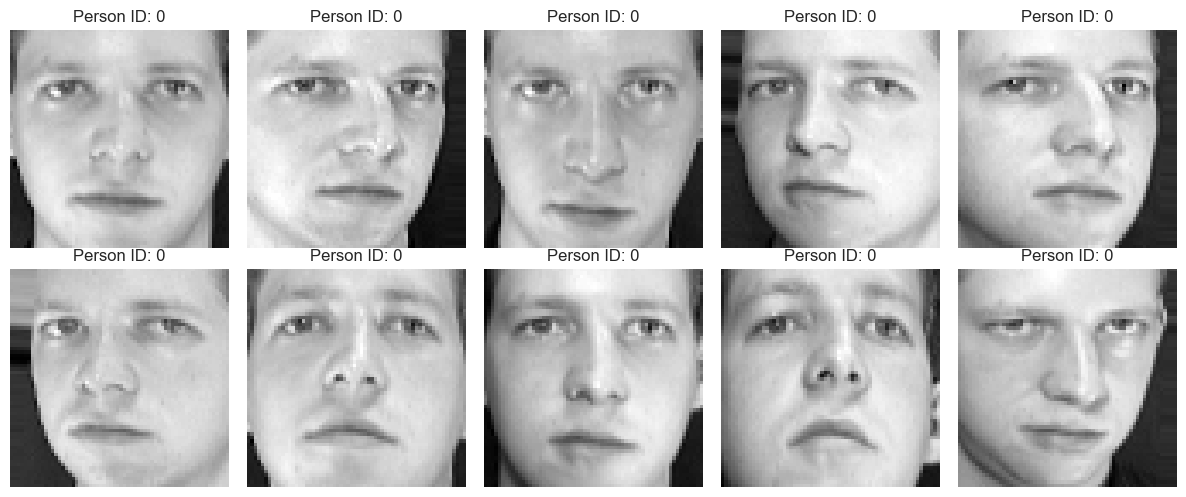

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), range(10)):
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f"Person ID: {y[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## **Prepare Training and Test Sets**

We split the dataset into training and test sets, then standardize the input features. Even though the face pixels are already scaled between 0 and 1, standardization often helps optimization when we train a neural network on flattened image features.

In [5]:
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, images, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Train samples per class: {np.bincount(y_train)[:5]} ...")

Training set size: 300
Test set size: 100
Train samples per class: [8 7 7 7 8] ...


## **TASK 1: Define the Classification Network**

Build a feed-forward neural network with:
- Input layer: `4096` features
- Hidden layer 1: `512` neurons + ReLU
- Hidden layer 2: `128` neurons + ReLU
- Output layer: `40` neurons

The output layer produces one score for each person ID in the dataset.

In [6]:
class FaceNet(nn.Module):
    def __init__(self):
        super().__init__()

        INPUT_DIM = 4096
        H1_DIM = 512
        H2_DIM = 128
        OUTPUT_DIM = 40

        self.fc1 = nn.Linear(INPUT_DIM, H1_DIM)
        self.fc2 = nn.Linear(H1_DIM, H2_DIM)
        self.fc3 = nn.Linear(H2_DIM, OUTPUT_DIM)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

classifier = FaceNet().to(device)
print(classifier)
print(f"Trainable parameters: {sum(p.numel() for p in classifier.parameters()):,}")

FaceNet(
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=40, bias=True)
)
Trainable parameters: 2,168,488


## **TASK 2: Define the Loss Function and Optimizer**

Use:
- `nn.CrossEntropyLoss()` for multiclass classification
- `optim.Adam(...)` as the optimizer

In [7]:
classification_criterion = nn.CrossEntropyLoss()
classification_optimizer = optim.Adam(classifier.parameters(), lr=0.001)

print(classification_criterion)
print(classification_optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## **TASK 3: Train the Classifier**

Train the network for several epochs and store the average loss after each epoch. Because this dataset is much smaller and more difficult than digit classification, we expect training to be less stable and test accuracy to be lower than in easier image tasks.

In [8]:
classification_epochs = 40
classification_losses = []

for epoch in range(classification_epochs):
    classifier.train()
    running_loss = 0.0

    for batch_features, batch_labels in trainloader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        classification_optimizer.zero_grad()
        outputs = classifier(batch_features)
        loss = classification_criterion(outputs, batch_labels)
        loss.backward()
        classification_optimizer.step()

        running_loss += loss.item() * batch_features.size(0)

    avg_loss = running_loss / len(trainloader.dataset)
    classification_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{classification_epochs} - average loss: {avg_loss:.4f}")

Epoch 1/40 - average loss: 2.8833
Epoch 2/40 - average loss: 0.6816
Epoch 3/40 - average loss: 0.1719
Epoch 4/40 - average loss: 0.0987
Epoch 5/40 - average loss: 0.0473
Epoch 6/40 - average loss: 0.0048
Epoch 7/40 - average loss: 0.0033
Epoch 8/40 - average loss: 0.0016
Epoch 9/40 - average loss: 0.0013
Epoch 10/40 - average loss: 0.0011
Epoch 11/40 - average loss: 0.0009
Epoch 12/40 - average loss: 0.0008
Epoch 13/40 - average loss: 0.0007
Epoch 14/40 - average loss: 0.0007
Epoch 15/40 - average loss: 0.0006
Epoch 16/40 - average loss: 0.0006
Epoch 17/40 - average loss: 0.0005
Epoch 18/40 - average loss: 0.0005
Epoch 19/40 - average loss: 0.0005
Epoch 20/40 - average loss: 0.0004
Epoch 21/40 - average loss: 0.0004
Epoch 22/40 - average loss: 0.0004
Epoch 23/40 - average loss: 0.0004
Epoch 24/40 - average loss: 0.0003
Epoch 25/40 - average loss: 0.0003
Epoch 26/40 - average loss: 0.0003
Epoch 27/40 - average loss: 0.0003
Epoch 28/40 - average loss: 0.0003
Epoch 29/40 - average loss: 0

## **Visualize the Training Loss**

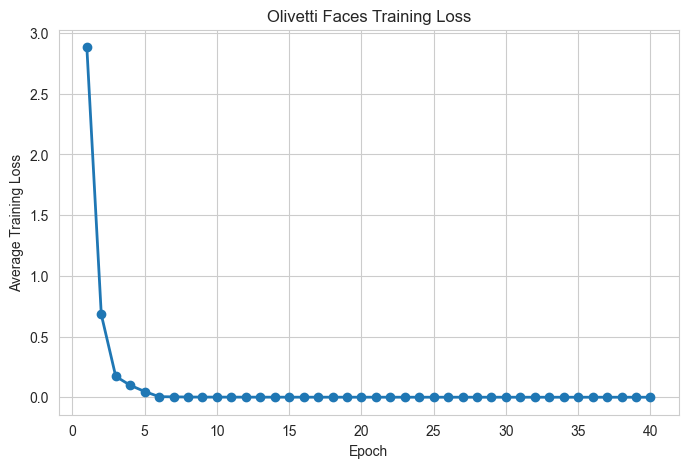

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, classification_epochs + 1), classification_losses, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.title('Olivetti Faces Training Loss')
plt.show()

## **TASK 4: Evaluate the Classifier**

Compute the test accuracy and inspect the classes with the highest and lowest test accuracy. A full 40x40 confusion matrix is possible, but a per-class summary is easier to interpret in this setting.

In [10]:
classifier.eval()
all_predictions = []
all_true = []

with torch.no_grad():
    for batch_features, batch_labels in testloader:
        batch_features = batch_features.to(device)
        outputs = classifier(batch_features)
        predictions = outputs.argmax(dim=1).cpu().numpy()
        all_predictions.extend(predictions)
        all_true.extend(batch_labels.numpy())

all_predictions = np.array(all_predictions)
all_true = np.array(all_true)
classification_accuracy = (all_predictions == all_true).mean() * 100
print(f"Test accuracy: {classification_accuracy:.2f}%")

cm = confusion_matrix(all_true, all_predictions, labels=np.arange(40))
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
per_class_df = pd.DataFrame({
    'person_id': np.arange(40),
    'accuracy': per_class_accuracy
}).sort_values('accuracy', ascending=False)

print('Top 10 person IDs by test accuracy:')
print(per_class_df.head(10))
print('Bottom 10 person IDs by test accuracy:')
print(per_class_df.tail(10))

Test accuracy: 96.00%
Top 10 person IDs by test accuracy:
    person_id  accuracy
1           1       1.0
2           2       1.0
3           3       1.0
4           4       1.0
6           6       1.0
5           5       1.0
7           7       1.0
8           8       1.0
32         32       1.0
10         10       1.0
Bottom 10 person IDs by test accuracy:
    person_id  accuracy
30         30  1.000000
31         31  1.000000
38         38  1.000000
37         37  1.000000
34         34  1.000000
35         35  1.000000
39         39  1.000000
21         21  0.666667
9           9  0.500000
0           0  0.000000


## **Inspect Example Predictions**

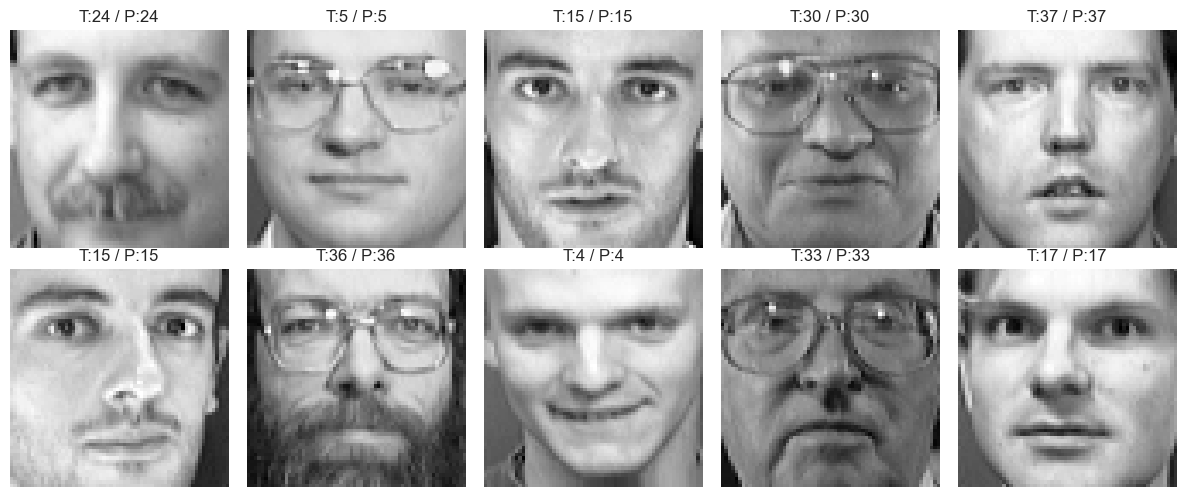

In [11]:
sample_indices = np.arange(10)
sample_features = torch.tensor(X_test_scaled[sample_indices], dtype=torch.float32).to(device)
sample_preds = classifier(sample_features).argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, image, true_label, pred_label in zip(axes.flatten(), img_test[sample_indices], y_test[sample_indices], sample_preds):
    ax.imshow(image, cmap='gray')
    ax.set_title(f"T:{true_label} / P:{pred_label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## **Part 1 Discussion**

### **Write your answers here**

1. **Why are hidden layers with ReLU useful here?**
   - WRITE ANSWER HERE

2. **Why standardize the 4,096 pixel features before training?**
   - WRITE ANSWER HERE

3. **Why is this task harder than digit classification?**
   - WRITE ANSWER HERE

4. **What does the per-class accuracy summary tell us?**
   - WRITE ANSWER HERE


# **Part 2: Learning Wine Embeddings with an Autoencoder**

In the lecture and in-class material, embeddings were discussed as learned representations. Here we will learn a different kind of embedding: a **latent representation** of tabular data.

We will use the built-in `sklearn` **wine** dataset. Each row describes a wine using chemical analysis features such as alcohol, flavanoids, color intensity, and proline. The wine class label will be used only for interpretation and visualization.

## **What is an Autoencoder?**

An autoencoder is a neural network trained to reproduce its input. It has two main parts:
- **Encoder**: compresses the original features into a low-dimensional latent vector
- **Decoder**: reconstructs the original features from that latent vector

The low-dimensional bottleneck acts as a learned **embedding** of the original data.

## **Load the Wine Dataset**

This time we use the built-in `load_wine()` dataset from `scikit-learn`, so the notebook remains fully self-contained.

In [12]:
wine_bunch = load_wine(as_frame=True)
wine_df = wine_bunch.frame.copy()
wine_features_df = wine_bunch.data.copy()
wine_class = wine_bunch.target.to_numpy()
wine_class_names = wine_bunch.target_names

print(wine_features_df.head())
print(f"\nShape: {wine_features_df.shape}")
print(f"Wine classes: {wine_class_names}")
print(f"Class distribution:\n{pd.Series(wine_class).value_counts().sort_index()}")

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

## **Prepare Input Features**

We separate the numeric chemistry features from the class labels, then standardize the inputs before training the autoencoder.

In [13]:
wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(wine_features_df).astype(np.float32)

X_wine_train, X_wine_test, class_train, class_test = train_test_split(
    X_wine_scaled, wine_class, test_size=0.2, random_state=42, stratify=wine_class
)

X_wine_train_tensor = torch.tensor(X_wine_train, dtype=torch.float32)
X_wine_test_tensor = torch.tensor(X_wine_test, dtype=torch.float32)

wine_trainloader = torch.utils.data.DataLoader(X_wine_train_tensor, batch_size=32, shuffle=True)

print(f"Training rows: {len(X_wine_train)}")
print(f"Test rows: {len(X_wine_test)}")
print(f"Number of input features: {X_wine_train.shape[1]}")

Training rows: 142
Test rows: 36
Number of input features: 13


## **TASK 5: Define the Autoencoder**

Build an autoencoder with:
- Encoder: `13 -> 16 -> 8 -> 2`
- Decoder: `2 -> 8 -> 16 -> 13`

The `2`-dimensional bottleneck is the learned wine embedding.

In [14]:
class WineAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

    def encode(self, x):
        return self.encoder(x)

autoencoder = WineAutoencoder(input_dim=X_wine_train.shape[1]).to(device)
print(autoencoder)

WineAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=13, bias=True)
  )
)


## **TASK 6: Define the Reconstruction Loss and Optimizer**

Because this is an autoencoder, the target output is the original input itself. We therefore use:
- **Mean Squared Error (MSE)** loss
- **Adam** optimizer

In [15]:
reconstruction_criterion = nn.MSELoss()
autoencoder_optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

print(reconstruction_criterion)
print(autoencoder_optimizer)

MSELoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## **TASK 7: Train the Autoencoder**

Train the model to reconstruct the standardized wine features and record the average reconstruction loss for each epoch.

In [16]:
autoencoder_epochs = 5000
autoencoder_losses = []

for epoch in range(autoencoder_epochs):
    autoencoder.train()
    running_loss = 0.0

    for batch_features in wine_trainloader:
        batch_features = batch_features.to(device)

        autoencoder_optimizer.zero_grad()
        reconstructed = autoencoder(batch_features)
        loss = reconstruction_criterion(reconstructed, batch_features)
        loss.backward()
        autoencoder_optimizer.step()

        running_loss += loss.item() * batch_features.size(0)

    avg_loss = running_loss / len(wine_trainloader.dataset)
    autoencoder_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{autoencoder_epochs} - average reconstruction loss: {avg_loss:.4f}")

Epoch 10/5000 - average reconstruction loss: 0.9880
Epoch 20/5000 - average reconstruction loss: 0.9048
Epoch 30/5000 - average reconstruction loss: 0.6817
Epoch 40/5000 - average reconstruction loss: 0.6258
Epoch 50/5000 - average reconstruction loss: 0.5777
Epoch 60/5000 - average reconstruction loss: 0.5232
Epoch 70/5000 - average reconstruction loss: 0.4749
Epoch 80/5000 - average reconstruction loss: 0.4551
Epoch 90/5000 - average reconstruction loss: 0.4422
Epoch 100/5000 - average reconstruction loss: 0.4301
Epoch 110/5000 - average reconstruction loss: 0.4178
Epoch 120/5000 - average reconstruction loss: 0.4052
Epoch 130/5000 - average reconstruction loss: 0.3948
Epoch 140/5000 - average reconstruction loss: 0.3871
Epoch 150/5000 - average reconstruction loss: 0.3795
Epoch 160/5000 - average reconstruction loss: 0.3739
Epoch 170/5000 - average reconstruction loss: 0.3693
Epoch 180/5000 - average reconstruction loss: 0.3653
Epoch 190/5000 - average reconstruction loss: 0.3612
Ep

## **Visualize Reconstruction Loss**

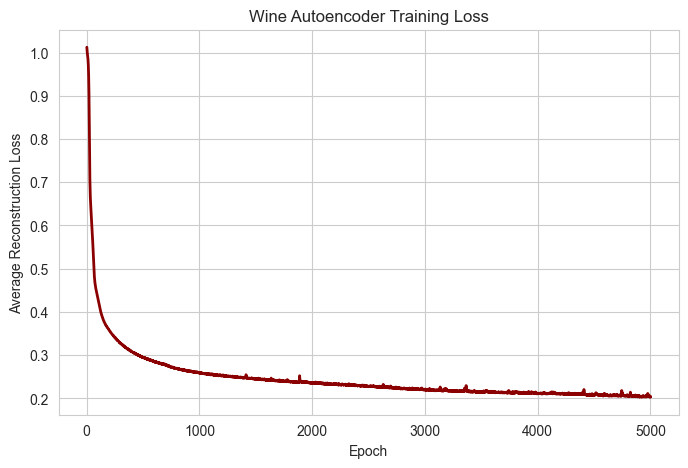

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, autoencoder_epochs + 1), autoencoder_losses, linewidth=2, color='darkred')
plt.xlabel('Epoch')
plt.ylabel('Average Reconstruction Loss')
plt.title('Wine Autoencoder Training Loss')
plt.show()

## **TASK 8: Extract and Visualize the 2D Wine Embeddings**

Use the encoder to map each wine into a 2-dimensional latent space, then visualize the result with a scatter plot colored by wine class.

Overall reconstruction MSE: 0.2755


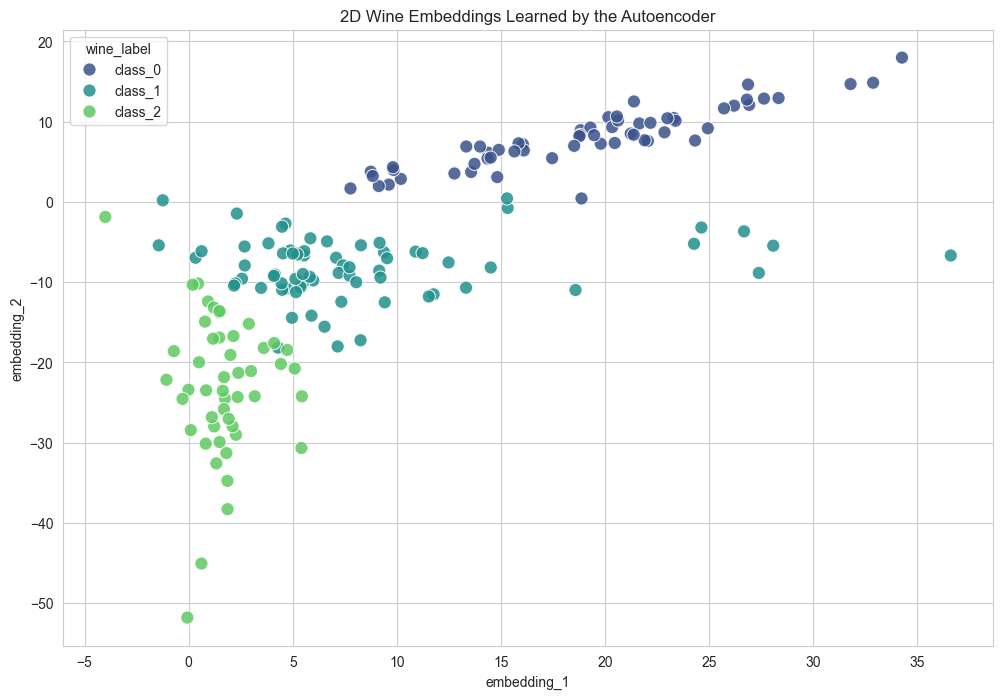

In [18]:
autoencoder.eval()
with torch.no_grad():
    full_wine_tensor = torch.tensor(X_wine_scaled, dtype=torch.float32).to(device)
    wine_embeddings = autoencoder.encode(full_wine_tensor).cpu().numpy()
    reconstructed_all = autoencoder(full_wine_tensor).cpu().numpy()

reconstruction_mse = np.mean((reconstructed_all - X_wine_scaled) ** 2)
print(f"Overall reconstruction MSE: {reconstruction_mse:.4f}")

embedding_df = pd.DataFrame({
    'embedding_1': wine_embeddings[:, 0],
    'embedding_2': wine_embeddings[:, 1],
    'wine_class': wine_class,
    'wine_label': [wine_class_names[idx] for idx in wine_class]
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=embedding_df,
    x='embedding_1',
    y='embedding_2',
    hue='wine_label',
    palette='viridis',
    alpha=0.85,
    s=90
)
plt.title('2D Wine Embeddings Learned by the Autoencoder')
plt.show()

## **Compare Average Embedding Position by Wine Class**

            embedding_1  embedding_2
wine_label                          
class_0       19.165600     7.994514
class_1        8.373858    -8.190701
class_2        1.676049   -23.033255


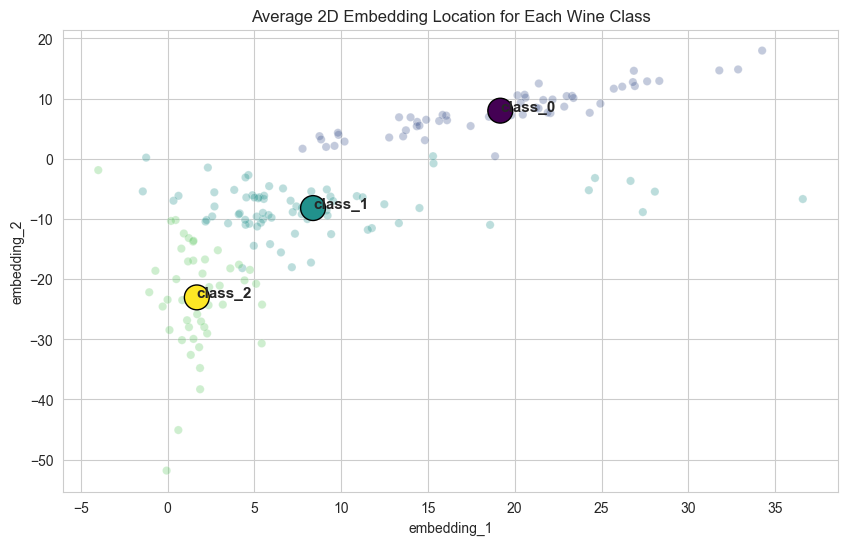

In [19]:
class_centers = embedding_df.groupby('wine_label')[['embedding_1', 'embedding_2']].mean()
print(class_centers)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=embedding_df,
    x='embedding_1',
    y='embedding_2',
    hue='wine_label',
    palette='viridis',
    alpha=0.3,
    legend=False
)
plt.scatter(
    class_centers['embedding_1'],
    class_centers['embedding_2'],
    s=320,
    c=np.arange(len(class_centers)),
    cmap='viridis',
    edgecolor='black'
)
for wine_label, row in class_centers.iterrows():
    plt.text(row['embedding_1'], row['embedding_2'], wine_label, fontsize=11, weight='bold')
plt.title('Average 2D Embedding Location for Each Wine Class')
plt.show()

## **Part 2 Discussion**

### **Write your answers here**

1. **What is the role of the bottleneck layer in the autoencoder?**
   - WRITE ANSWER HERE

2. **Why do we use MSE loss instead of cross entropy here?**
   - WRITE ANSWER HERE

3. **What does the 2D embedding plot tell us?**
   - WRITE ANSWER HERE

4. **How is this an embedding task?**
   - WRITE ANSWER HERE

5. **How could this model be improved?**
   - WRITE ANSWER HERE

## **Summary and Key Takeaways**

### **What we learned**

1. **Neural networks for classification**
   - A feed-forward network can classify face images from pixel features.
   - Cross entropy loss and Adam optimization work well for multiclass classification.

2. **Neural networks for representation learning**
   - Neural networks can also learn compact latent representations, not just class labels.
   - Autoencoders learn embeddings by compressing and reconstructing the original data.

3. **Different losses for different goals**
   - Classification tasks often use **cross entropy**.
   - Reconstruction tasks often use **mean squared error**.

4. **Embeddings are broader than word vectors**
   - In this homework, the wine latent vectors are embeddings learned from tabular features.
   - Embeddings are any learned low-dimensional representations that preserve useful structure.

### **Big Picture**

Neural networks are flexible tools. The same building blocks from the lecture, layers, activations, loss functions, backpropagation, and optimizers, can be used for both **prediction** and **representation learning**.